#Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#Upload and Load the Dataset

In [2]:
from google.colab import files
print("Please select and upload: covid_vaccine_statewise.csv")
uploaded = files.upload()

Please select and upload: covid_vaccine_statewise.csv


Saving covid_vaccine_statewise.csv to covid_vaccine_statewise.csv


In [2]:
fn = 'covid_vaccine_statewise.csv'
df = pd.read_csv(fn, encoding='utf-8')
print(f"\nLoaded '{fn}' with shape:", df.shape)


Loaded 'covid_vaccine_statewise.csv' with shape: (7845, 24)


#Basic Dataset Description

In [3]:
df.head(10)

,Updated On,State,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
0,16/01/2021,India,48276.0,3455.0,2957.0,48276.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,23757.0,24517.0,2.0,48276.0
1,17/01/2021,India,58604.0,8532.0,4954.0,58604.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27348.0,31252.0,4.0,58604.0
2,18/01/2021,India,99449.0,13611.0,6583.0,99449.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41361.0,58083.0,5.0,99449.0
3,19/01/2021,India,195525.0,17855.0,7951.0,195525.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,81901.0,113613.0,11.0,195525.0
4,20/01/2021,India,251280.0,25472.0,10504.0,251280.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,98111.0,153145.0,24.0,251280.0
5,21/01/2021,India,365965.0,32226.0,12600.0,365965.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,132784.0,233143.0,38.0,365965.0
6,22/01/2021,India,549381.0,36988.0,14115.0,549381.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,193899.0,355402.0,80.0,549381.0
7,23/01/2021,India,759008.0,43076.0,15605.0,759008.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,267856.0,491049.0,103.0,759008.0
8,24/01/2021,India,835058.0,49851.0,18111.0,835058.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,296283.0,538647.0,128.0,835058.0
9,25/01/2021,India,1277104.0,55151.0,19682.0,1277104.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,444137.0,832766.0,201.0,1277104.0


In [7]:
df = df[df['State'].str.lower() != 'india']


In [4]:
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7845 entries, 0 to 7844
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Updated On                           7845 non-null   object 
 1   State                                7845 non-null   object 
 2   Total Doses Administered             7621 non-null   float64
 3   Sessions                             7621 non-null   float64
 4    Sites                               7621 non-null   float64
 5   First Dose Administered              7621 non-null   float64
 6   Second Dose Administered             7621 non-null   float64
 7   Male (Doses Administered)            7461 non-null   float64
 8   Female (Doses Administered)          7461 non-null   float64
 9   Transgender (Doses Administered)     7461 non-null   float64
 10   Covaxin (Doses Administered)        7621 non-null   float64
 11  CoviShie

In [5]:
print("\n--- Numeric Summary ---")
display(df.describe())


--- Numeric Summary ---


,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),Covaxin (Doses Administered),CoviShield (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
count,7.621000e+03,7.621000e+03,7621.000000,7.621000e+03,7.621000e+03,7.461000e+03,7.461000e+03,7461.000000,7.621000e+03,7.621000e+03,...,1.702000e+03,1.702000e+03,1.702000e+03,3.733000e+03,3.734000e+03,3.734000e+03,1.600000e+02,1.600000e+02,160.000000,5.919000e+03
mean,9.188171e+06,4.792358e+05,2282.872064,7.414415e+06,1.773755e+06,3.620156e+06,3.168416e+06,1162.978019,1.044669e+06,8.126553e+06,...,8.773958e+06,7.442161e+06,5.641605e+06,1.395895e+06,2.916515e+06,2.627444e+06,4.461687e+07,3.951018e+07,12370.543750,4.547842e+06
std,3.746180e+07,1.911511e+06,7275.973730,2.995209e+07,7.570382e+06,1.737938e+07,1.515310e+07,5931.353995,4.452259e+06,3.298414e+07,...,2.660829e+07,2.225999e+07,1.681650e+07,5.501454e+06,9.567607e+06,8.192225e+06,3.950749e+07,3.417684e+07,12485.026753,1.834182e+07
min,7.000000e+00,0.000000e+00,0.000000,7.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000,0.000000e+00,7.000000e+00,...,2.662400e+04,1.681500e+04,9.994000e+03,1.059000e+03,1.136000e+03,5.580000e+02,2.375700e+04,2.451700e+04,2.000000,7.000000e+00
25%,1.356570e+05,6.004000e+03,69.000000,1.166320e+05,1.283100e+04,5.655500e+04,5.210700e+04,8.000000,0.000000e+00,1.331340e+05,...,4.344842e+05,2.326275e+05,1.285605e+05,5.655400e+04,9.248225e+04,5.615975e+04,5.739350e+06,5.023407e+06,1278.750000,7.427550e+04
50%,8.182020e+05,4.547000e+04,597.000000,6.614590e+05,1.388180e+05,3.897850e+05,3.342380e+05,113.000000,1.185100e+04,7.567360e+05,...,3.095970e+06,2.695938e+06,1.805696e+06,2.947270e+05,8.330395e+05,7.887425e+05,3.716590e+07,3.365402e+07,8007.500000,4.022880e+05
75%,6.625243e+06,3.428690e+05,1708.000000,5.387805e+06,1.166434e+06,2.735777e+06,2.561513e+06,800.000000,7.579300e+05,6.007817e+06,...,7.366241e+06,6.969726e+06,5.294763e+06,9.105160e+05,2.499280e+06,2.337874e+06,7.441663e+07,6.685368e+07,19851.000000,3.501562e+06
max,5.132284e+08,3.501031e+07,73933.000000,4.001504e+08,1.130780e+08,2.701636e+08,2.395186e+08,98275.000000,6.236742e+07,4.468251e+08,...,2.243304e+08,1.667575e+08,1.186927e+08,9.224315e+07,9.096888e+07,6.731098e+07,1.349420e+08,1.156684e+08,46462.000000,2.506569e+08


In [6]:
print(f"No. of Rows : {df.shape[0]}\nNo. of Columns : {df.shape[1]}")

No. of Rows : 7845
No. of Columns : 24


In [7]:
print("\n--- Missing Values per Column ---")
print(df.isnull().sum())


--- Missing Values per Column ---
Updated On                                0
State                                     0
Total Doses Administered                224
Sessions                                224
 Sites                                  224
First Dose Administered                 224
Second Dose Administered                224
Male (Doses Administered)               384
Female (Doses Administered)             384
Transgender (Doses Administered)        384
 Covaxin (Doses Administered)           224
CoviShield (Doses Administered)         224
Sputnik V (Doses Administered)         4850
AEFI                                   2407
18-44 Years (Doses Administered)       6143
45-60 Years (Doses Administered)       6143
60+ Years (Doses Administered)         6143
18-44 Years(Individuals Vaccinated)    4112
45-60 Years(Individuals Vaccinated)    4111
60+ Years(Individuals Vaccinated)      4111
Male(Individuals Vaccinated)           7685
Female(Individuals Vaccinated)         76

#Clean Column Names and Dates

##Trim Whitespace

In [8]:
df.columns = df.columns.str.strip()

##Convert Date to datetime

In [9]:
if 'Updated On' in df.columns:
    df['Updated On'] = pd.to_datetime(df['Updated On'], dayfirst=True)

print("\nCleaned Columns:")
print(df.columns.tolist())


Cleaned Columns:
['Updated On', 'State', 'Total Doses Administered', 'Sessions', 'Sites', 'First Dose Administered', 'Second Dose Administered', 'Male (Doses Administered)', 'Female (Doses Administered)', 'Transgender (Doses Administered)', 'Covaxin (Doses Administered)', 'CoviShield (Doses Administered)', 'Sputnik V (Doses Administered)', 'AEFI', '18-44 Years (Doses Administered)', '45-60 Years (Doses Administered)', '60+ Years (Doses Administered)', '18-44 Years(Individuals Vaccinated)', '45-60 Years(Individuals Vaccinated)', '60+ Years(Individuals Vaccinated)', 'Male(Individuals Vaccinated)', 'Female(Individuals Vaccinated)', 'Transgender(Individuals Vaccinated)', 'Total Individuals Vaccinated']


#Statewise First Dose Totals

In [10]:
first_col = 'First Dose Administered'
if first_col not in df.columns:
    raise ValueError(f"Expected column '{first_col}' not found.")

state_first = (
    df
    .groupby('State')[first_col]
    .sum()
    .reset_index()
    .sort_values(by=first_col, ascending=False)
)
print(f"\n--- State-wise Totals for {first_col} ---")
display(state_first)


--- State-wise Totals for First Dose Administered ---


,State,First Dose Administered
13,India,2.826214e+10
34,Uttar Pradesh,2.788411e+09
21,Maharashtra,2.784364e+09
29,Rajasthan,2.201044e+09
10,Gujarat,2.131646e+09
16,Karnataka,1.873330e+09
20,Madhya Pradesh,1.796605e+09
36,West Bengal,1.796450e+09
4,Bihar,1.470503e+09
31,Tamil Nadu,1.288533e+09


##Visualizing via BarChart

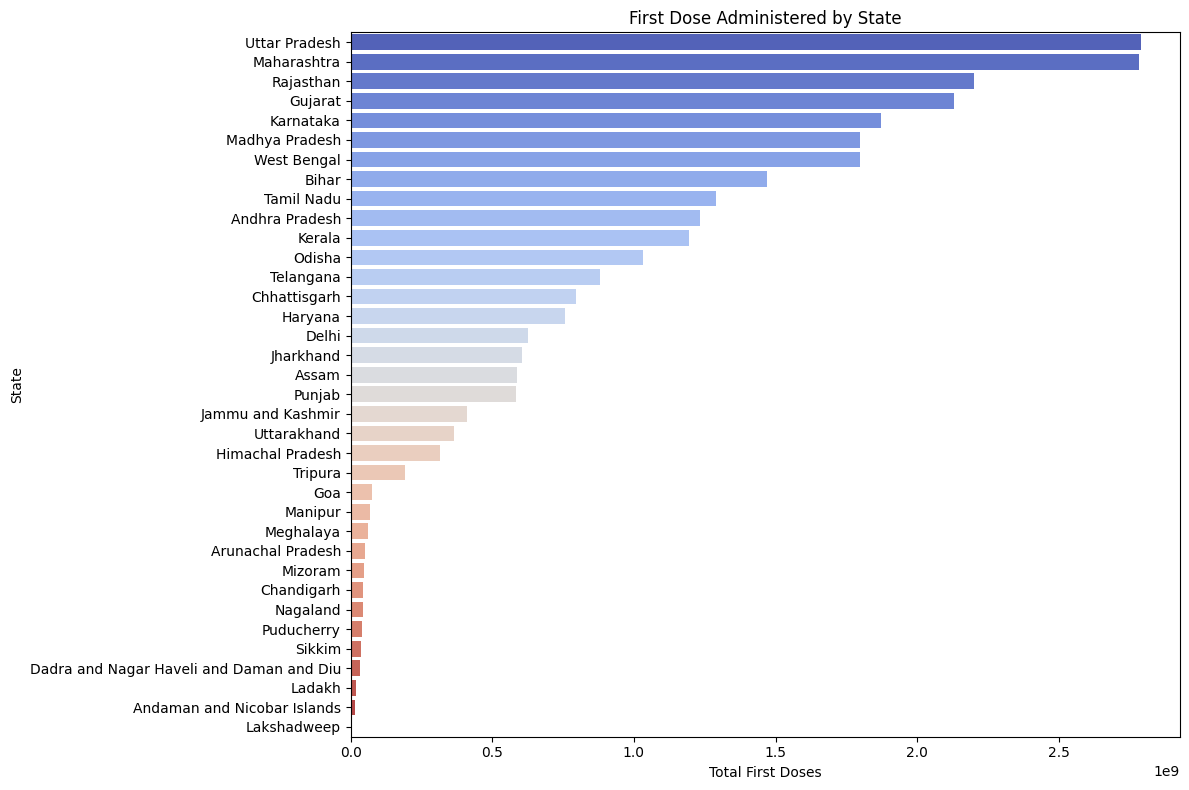

In [18]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=state_first[state_first['State'].str.lower() != 'india'],  # Filter out 'India'
    y='State',
    x=first_col,
    palette='coolwarm'
)
plt.title('First Dose Administered by State')
plt.xlabel('Total First Doses')
plt.ylabel('State')
plt.tight_layout()
plt.show()

#Statewise Second Dose Totals

In [12]:
second_col = 'Second Dose Administered'
if second_col not in df.columns:
    raise ValueError(f"Expected column '{second_col}' not found.")

state_second = (
    df
    .groupby('State')[second_col]
    .sum()
    .reset_index()
    .sort_values(by=second_col, ascending=False)
)
print(f"\n--- State-wise Totals for {second_col} ---")
display(state_second)


--- State-wise Totals for Second Dose Administered ---


,State,Second Dose Administered
13,India,6.759621e+09
21,Maharashtra,7.128811e+08
10,Gujarat,6.004184e+08
36,West Bengal,5.861469e+08
34,Uttar Pradesh,5.544351e+08
29,Rajasthan,4.917030e+08
16,Karnataka,4.271872e+08
17,Kerala,3.640488e+08
1,Andhra Pradesh,3.588176e+08
20,Madhya Pradesh,3.169330e+08


##Visualizing via BarChart

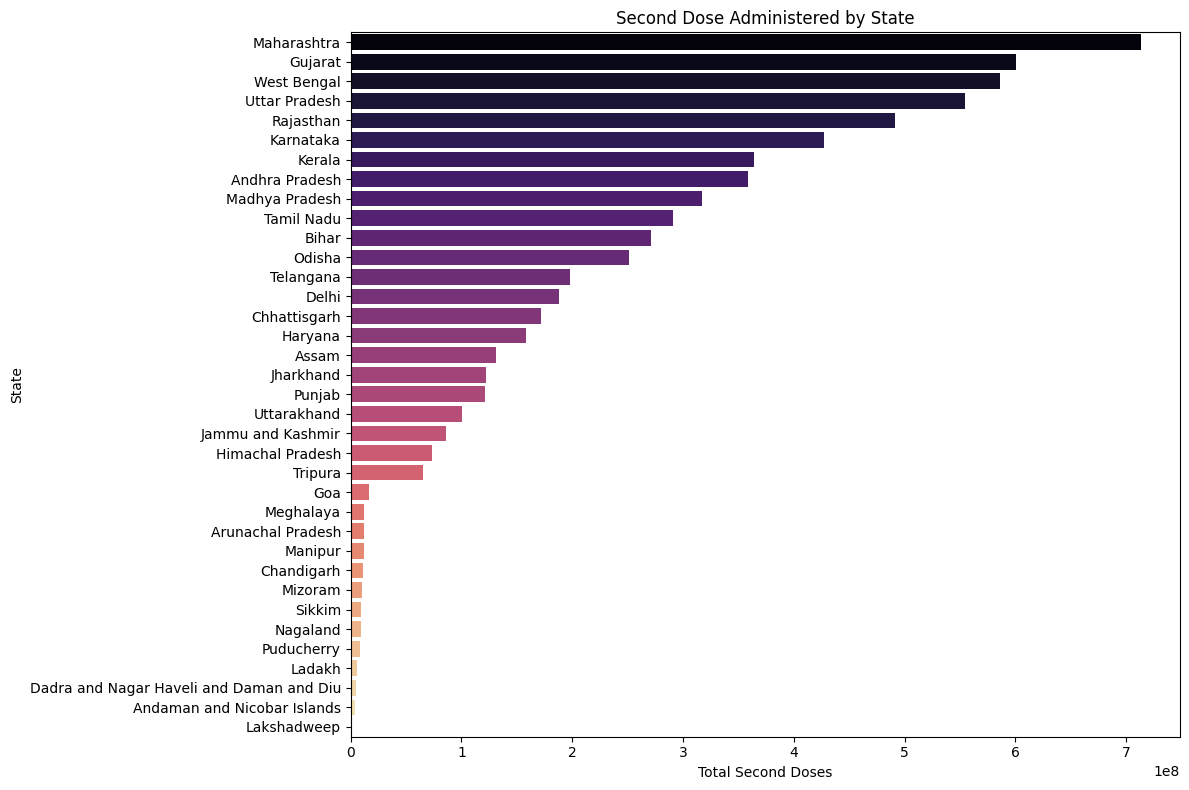

In [19]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=state_second[state_second['State'].str.lower() != 'india'],  # Exclude 'India'
    y='State',
    x=second_col,
    palette='magma'
)
plt.title('Second Dose Administered by State')
plt.xlabel('Total Second Doses')
plt.ylabel('State')
plt.tight_layout()
plt.show()

#Total Males Vaccinated

In [14]:
male_cols = [c for c in df.columns
             if 'male' in c.lower() and 'vaccinated' in c.lower()]
if not male_cols:
    print("⚠️ Could not find a Male‑Vaccinated column.")
else:
    male_col = male_cols[0]
    total_males = df[male_col].sum()
    print(f"\nTotal Males Vaccinated ({male_col}): {total_males:,}")


Total Males Vaccinated (Male(Individuals Vaccinated)): 7,138,698,858.0


#Total Females Vaccinated

In [15]:
female_cols = [c for c in df.columns
               if 'female' in c.lower() and 'vaccinated' in c.lower()]
if not female_cols:
    print("⚠️ Could not find a Female‑Vaccinated column.")
else:
    female_col = female_cols[0]
    total_females = df[female_col].sum()
    print(f"\nTotal Females Vaccinated ({female_col}): {total_females:,}")


Total Females Vaccinated (Female(Individuals Vaccinated)): 6,321,628,736.0


#Visualize Total Males vs Total Females Vaccinated

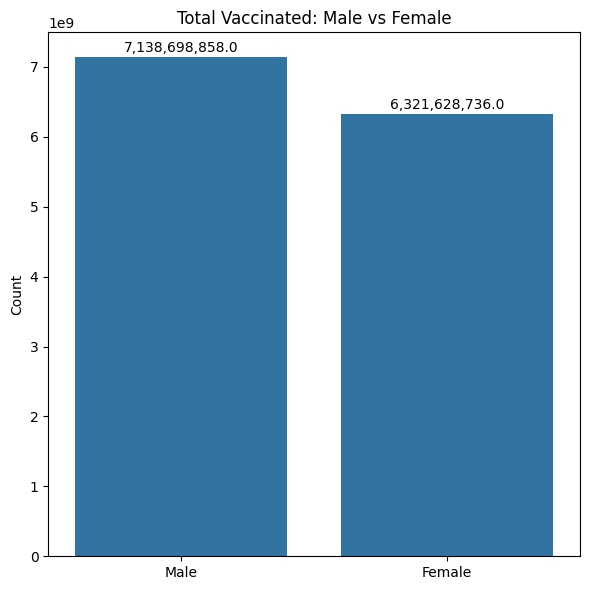

In [16]:
plt.figure(figsize=(6,6))
counts = [total_males, total_females]
labels = ['Male', 'Female']
sns.barplot(x=labels, y=counts)
plt.title('Total Vaccinated: Male vs Female')
plt.ylabel('Count')
for i, v in enumerate(counts):
    plt.text(i, v + counts[0]*0.01, f"{v:,}", ha='center')
plt.tight_layout()
plt.show()

#Quick Tabulation

In [17]:
summary = pd.DataFrame({
    'State': state_first['State'],
    'First Dose': state_first[first_col].values,
    'Second Dose': state_second[second_col].values,
})
print("\n--- Combined State-wise Summary ---")
display(summary)


--- Combined State-wise Summary ---


,State,First Dose,Second Dose
13,India,2.826214e+10,6.759621e+09
34,Uttar Pradesh,2.788411e+09,7.128811e+08
21,Maharashtra,2.784364e+09,6.004184e+08
29,Rajasthan,2.201044e+09,5.861469e+08
10,Gujarat,2.131646e+09,5.544351e+08
16,Karnataka,1.873330e+09,4.917030e+08
20,Madhya Pradesh,1.796605e+09,4.271872e+08
36,West Bengal,1.796450e+09,3.640488e+08
4,Bihar,1.470503e+09,3.588176e+08
31,Tamil Nadu,1.288533e+09,3.169330e+08
